# 01 — Phân tích dữ liệu chất lượng không khí Hà Nội

Notebook trả lời sáu câu hỏi EDA chính của project:

1. PM2.5 cao nhất vào giờ nào?
2. Ngày nào trong tuần ô nhiễm cao?
3. PM2.5 có liên quan đến độ ẩm không?
4. Gió mạnh có làm giảm ô nhiễm không?
5. Khu vực nào thường xuyên vượt ngưỡng?
6. Có chu kỳ theo giờ hay theo mùa không?

**Dữ liệu:** bảng đã làm sạch `data/processed/air_quality_clean.csv`, múi giờ `Asia/Ho_Chi_Minh`. Các dòng được pipeline gắn `is_possible_outlier=True` được loại khỏi thống kê EDA.

## 1. Thiết lập và đọc dữ liệu

Notebook chạy được khi mở JupyterLab từ thư mục gốc project hoặc từ thư mục `notebooks/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
DATA_PATH = ROOT / 'data' / 'processed' / 'air_quality_clean.csv'
REPORT_PATH = ROOT / 'data' / 'processed' / 'cleaning_report.json'
assert DATA_PATH.exists(), f'Không tìm thấy dữ liệu: {DATA_PATH}'
DATA_PATH

WindowsPath('D:/Blue AI/AirPolltion/data/processed/air_quality_clean.csv')

In [2]:
columns = [
    'timestamp', 'station_id', 'location_name', 'pm25', 'humidity',
    'wind_speed', 'is_possible_outlier', 'data_quality_score'
]
df = pd.read_csv(DATA_PATH, usecols=columns, low_memory=False)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
df['is_possible_outlier'] = df['is_possible_outlier'].fillna(False).astype(bool)

quality_summary = pd.Series({
    'Số dòng': len(df),
    'Số khu vực': df['station_id'].nunique(),
    'Bắt đầu': df['timestamp'].min(),
    'Kết thúc': df['timestamp'].max(),
    'PM2.5 thiếu': int(df['pm25'].isna().sum()),
    'Dòng có cờ outlier': int(df['is_possible_outlier'].sum()),
    'Khóa trùng': int(df.duplicated(['timestamp', 'station_id']).sum()),
})
display(quality_summary.to_frame('Giá trị'))

analysis_df = df.loc[~df['is_possible_outlier']].dropna(
    subset=['pm25', 'humidity', 'wind_speed']
).copy()
analysis_df['hour'] = analysis_df['timestamp'].dt.hour
analysis_df['weekday'] = analysis_df['timestamp'].dt.dayofweek
analysis_df['month'] = analysis_df['timestamp'].dt.month
analysis_df['year'] = analysis_df['timestamp'].dt.year
analysis_df['date'] = analysis_df['timestamp'].dt.date
print(f'Dùng {len(analysis_df):,} dòng cho EDA sau khi loại cờ outlier.')

,Giá trị
Số dòng,267976
Số khu vực,8
Bắt đầu,2022-08-04 07:00:00+07:00
Kết thúc,2026-05-30 23:00:00+07:00
PM2.5 thiếu,0
Dòng có cờ outlier,462
Khóa trùng,0


Dùng 267,514 dòng cho EDA sau khi loại cờ outlier.


## 2. PM2.5 cao nhất vào giờ nào?

Phân biệt hai kết quả: thời điểm có quan sát cao nhất và giờ trong ngày có PM2.5 trung bình cao nhất trên toàn bộ giai đoạn.

,Chỉ tiêu,Kết quả
0,Quan sát PM2.5 lớn nhất,258.0 µg/m³ — Thanh Xuan — 2025-04-15 05:00:00...
1,Giờ có PM2.5 trung bình cao nhất,20:00 — trung bình 56.3 µg/m³


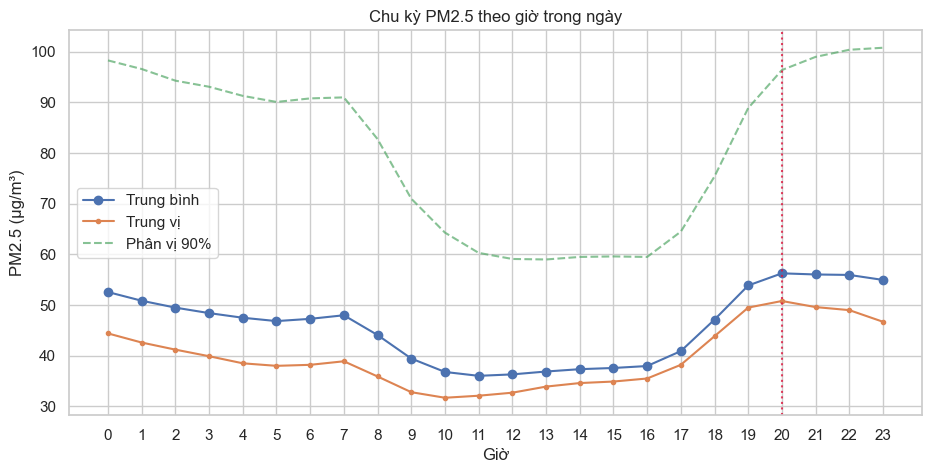

In [3]:
max_row = analysis_df.loc[analysis_df['pm25'].idxmax()]
hour_stats = analysis_df.groupby('hour')['pm25'].agg(
    mean='mean', median='median', p90=lambda x: x.quantile(0.90), count='size'
).reset_index()
peak_hour_row = hour_stats.loc[hour_stats['mean'].idxmax()]

display(pd.DataFrame({
    'Chỉ tiêu': ['Quan sát PM2.5 lớn nhất', 'Giờ có PM2.5 trung bình cao nhất'],
    'Kết quả': [
        f"{max_row['pm25']:.1f} µg/m³ — {max_row['location_name']} — {max_row['timestamp']}",
        f"{int(peak_hour_row['hour']):02d}:00 — trung bình {peak_hour_row['mean']:.1f} µg/m³",
    ]
}))

fig, ax = plt.subplots()
ax.plot(hour_stats['hour'], hour_stats['mean'], marker='o', label='Trung bình')
ax.plot(hour_stats['hour'], hour_stats['median'], marker='.', label='Trung vị')
ax.plot(hour_stats['hour'], hour_stats['p90'], linestyle='--', alpha=.7, label='Phân vị 90%')
ax.axvline(peak_hour_row['hour'], color='crimson', linestyle=':', alpha=.8)
ax.set(title='Chu kỳ PM2.5 theo giờ trong ngày', xlabel='Giờ', ylabel='PM2.5 (µg/m³)', xticks=range(24))
ax.legend()
plt.show()

## 3. Ngày nào trong tuần ô nhiễm cao?

,day,mean,median,p90,count
0,Thứ Hai,46.87,39.0,87.3,38125
1,Thứ Ba,46.71,39.8,85.2,38130
2,Thứ Tư,46.16,39.7,83.1,38079
3,Thứ Năm,45.97,40.2,81.7,38310
4,Thứ Sáu,44.90,38.1,80.8,38382
5,Thứ Bảy,44.39,38.1,78.0,38336
6,Chủ Nhật,45.32,37.6,84.3,38152


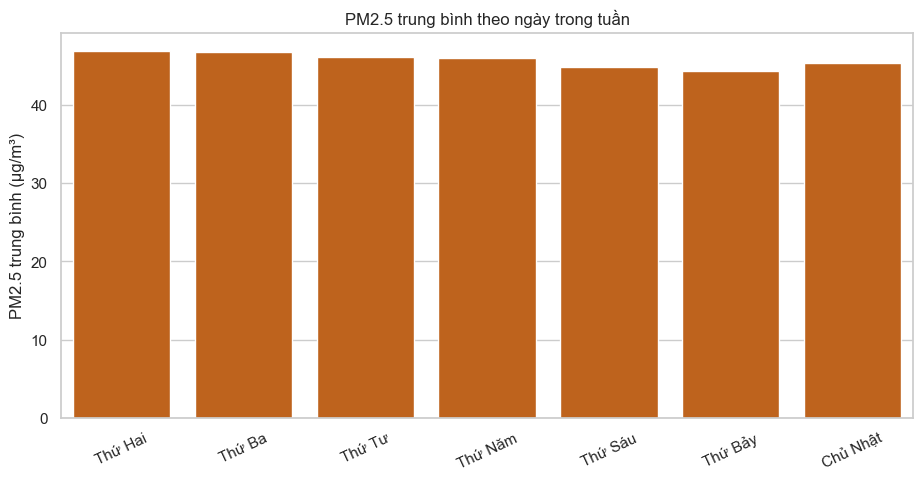

**Kết luận:** Thứ Hai có PM2.5 trung bình cao nhất: **46.9 µg/m³**. Chênh lệch nhỏ giữa các ngày cần được diễn giải thận trọng.

In [4]:
weekday_names = {
    0: 'Thứ Hai', 1: 'Thứ Ba', 2: 'Thứ Tư', 3: 'Thứ Năm',
    4: 'Thứ Sáu', 5: 'Thứ Bảy', 6: 'Chủ Nhật'
}
weekday_stats = analysis_df.groupby('weekday')['pm25'].agg(
    mean='mean', median='median', p90=lambda x: x.quantile(.90), count='size'
).reindex(range(7)).reset_index()
weekday_stats['day'] = weekday_stats['weekday'].map(weekday_names)
worst_weekday = weekday_stats.loc[weekday_stats['mean'].idxmax()]
display(weekday_stats[['day', 'mean', 'median', 'p90', 'count']].round(2))

ax = sns.barplot(data=weekday_stats, x='day', y='mean', color='#d95f02')
ax.set(title='PM2.5 trung bình theo ngày trong tuần', xlabel='', ylabel='PM2.5 trung bình (µg/m³)')
plt.xticks(rotation=25)
plt.show()
display(Markdown(
    f"**Kết luận:** {worst_weekday['day']} có PM2.5 trung bình cao nhất: "
    f"**{worst_weekday['mean']:.1f} µg/m³**. Chênh lệch nhỏ giữa các ngày cần được diễn giải thận trọng."
))

## 4. PM2.5 có liên quan đến độ ẩm không?

Tính cả Pearson (tuyến tính) và Spearman (đơn điệu). Tương quan không chứng minh quan hệ nhân quả; độ ẩm có thể đồng biến với mùa, nhiệt độ và điều kiện khí quyển khác.

,Tương quan PM2.5–độ ẩm
Pearson r,0.101
Spearman r,0.070


,spearman_r
location_name,
Long Bien,0.085
Cau Giay,0.084
Ha Dong,0.073
Thanh Xuan,0.073
Hai Ba Trung,0.062
Hoan Kiem,0.062
Ba Dinh,0.062
Dong Da,0.062


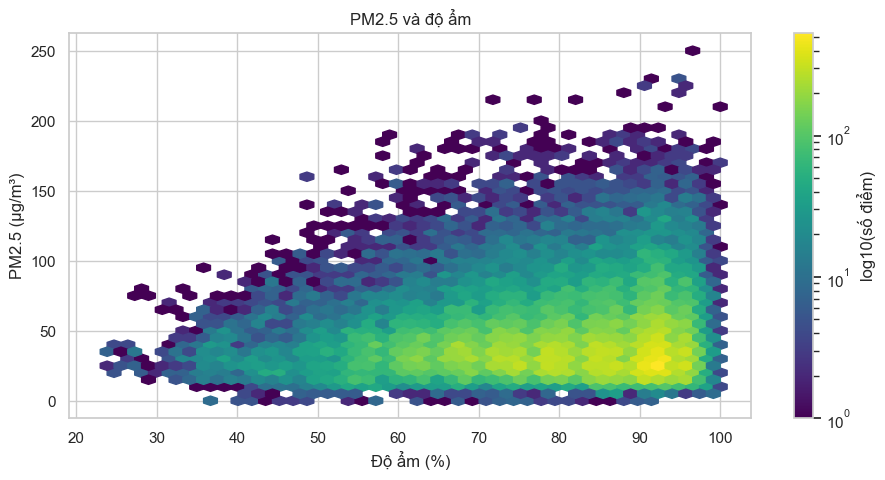

**Kết luận:** Spearman r = **0.070**, cho thấy liên hệ cùng chiều ở mức yếu; đây là liên hệ thống kê, không phải bằng chứng nhân quả.

In [5]:
humidity_corr_pearson = analysis_df['pm25'].corr(analysis_df['humidity'], method='pearson')
humidity_corr_spearman = analysis_df['pm25'].corr(analysis_df['humidity'], method='spearman')
humidity_by_station = analysis_df.groupby('location_name').apply(
    lambda x: x['pm25'].corr(x['humidity'], method='spearman'),
).sort_values(ascending=False).rename('spearman_r')
display(pd.Series({
    'Pearson r': humidity_corr_pearson,
    'Spearman r': humidity_corr_spearman,
}).round(3).to_frame('Tương quan PM2.5–độ ẩm'))
display(humidity_by_station.round(3).to_frame())

plot_sample = analysis_df.sample(min(60000, len(analysis_df)), random_state=42)
fig, ax = plt.subplots()
hb = ax.hexbin(plot_sample['humidity'], plot_sample['pm25'], gridsize=45, bins='log', mincnt=1, cmap='viridis')
fig.colorbar(hb, ax=ax, label='log10(số điểm)')
ax.set(title='PM2.5 và độ ẩm', xlabel='Độ ẩm (%)', ylabel='PM2.5 (µg/m³)')
plt.show()

direction = 'cùng chiều' if humidity_corr_spearman > 0 else 'ngược chiều'
strength = 'yếu' if abs(humidity_corr_spearman) < .3 else ('trung bình' if abs(humidity_corr_spearman) < .6 else 'mạnh')
display(Markdown(
    f"**Kết luận:** Spearman r = **{humidity_corr_spearman:.3f}**, cho thấy liên hệ "
    f"{direction} ở mức {strength}; đây là liên hệ thống kê, không phải bằng chứng nhân quả."
))

## 5. Gió mạnh có làm giảm ô nhiễm không?

So sánh nhóm gió yếu (≤ phân vị 25%) với gió mạnh (≥ phân vị 75%), đồng thời tính tương quan Spearman.

,Nhóm,PM2.5 trung bình,PM2.5 trung vị,Số quan sát
0,Gió yếu ≤ 4.7 km/h,58.28,50.8,67419
1,Gió mạnh ≥ 9.9 km/h,32.21,28.5,67992


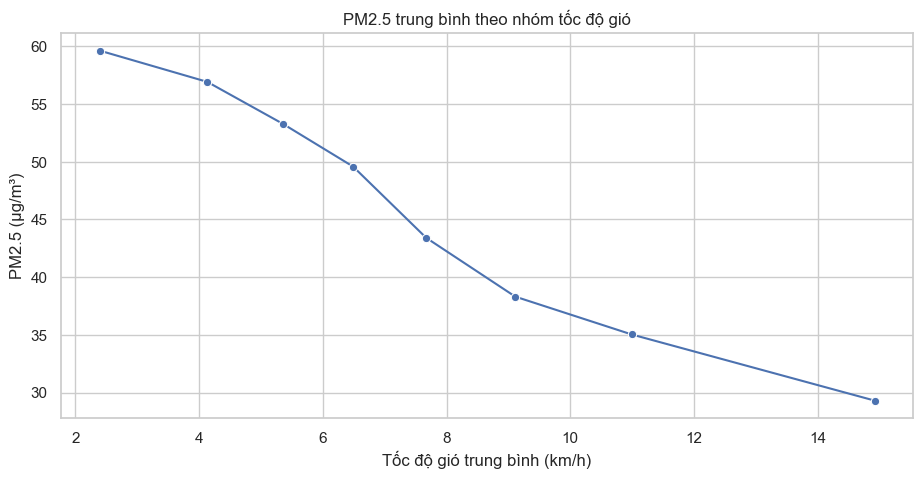

**Kết luận:** nhóm gió mạnh có PM2.5 trung bình thấp hơn nhóm gió yếu **44.7%**; Spearman r = **-0.407**. Kết quả ủng hộ giả thuyết gió giúp khuếch tán ô nhiễm, nhưng chưa kiểm soát mùa và mưa.

In [6]:
wind_q25, wind_q75 = analysis_df['wind_speed'].quantile([.25, .75])
weak_wind = analysis_df.loc[analysis_df['wind_speed'] <= wind_q25, 'pm25']
strong_wind = analysis_df.loc[analysis_df['wind_speed'] >= wind_q75, 'pm25']
wind_corr = analysis_df['pm25'].corr(analysis_df['wind_speed'], method='spearman')
wind_reduction = (weak_wind.mean() - strong_wind.mean()) / weak_wind.mean() * 100

wind_summary = pd.DataFrame({
    'Nhóm': [f'Gió yếu ≤ {wind_q25:.1f} km/h', f'Gió mạnh ≥ {wind_q75:.1f} km/h'],
    'PM2.5 trung bình': [weak_wind.mean(), strong_wind.mean()],
    'PM2.5 trung vị': [weak_wind.median(), strong_wind.median()],
    'Số quan sát': [len(weak_wind), len(strong_wind)],
})
display(wind_summary.round(2))

wind_bins = analysis_df.assign(
    wind_group=pd.qcut(analysis_df['wind_speed'], 8, duplicates='drop')
).groupby('wind_group', observed=True).agg(
    wind_speed=('wind_speed', 'mean'), pm25=('pm25', 'mean')
).reset_index(drop=True)
ax = sns.lineplot(data=wind_bins, x='wind_speed', y='pm25', marker='o')
ax.set(title='PM2.5 trung bình theo nhóm tốc độ gió', xlabel='Tốc độ gió trung bình (km/h)', ylabel='PM2.5 (µg/m³)')
plt.show()

conclusion = 'thấp hơn' if wind_reduction > 0 else 'cao hơn'
wind_interpretation = (
    'Kết quả ủng hộ giả thuyết gió giúp khuếch tán ô nhiễm'
    if wind_reduction > 0 and wind_corr < 0
    else 'Kết quả chưa ủng hộ rõ giả thuyết gió giúp khuếch tán ô nhiễm'
)
display(Markdown(
    f"**Kết luận:** nhóm gió mạnh có PM2.5 trung bình {conclusion} nhóm gió yếu "
    f"**{abs(wind_reduction):.1f}%**; Spearman r = **{wind_corr:.3f}**. "
    f"{wind_interpretation}, nhưng chưa kiểm soát mùa và mưa."
))

## 6. Khu vực nào thường xuyên vượt ngưỡng?

Dùng **trung bình ngày** PM2.5. Theo QCVN 05:2023/BTNMT, giới hạn PM2.5 trung bình 24 giờ là 50 µg/Nm³ và áp dụng 45 µg/Nm³ từ 01/01/2026.

Nguồn chính thức: [QCVN 05:2023/BTNMT](https://datafiles.chinhphu.vn/cpp/files/vbpq/2023/3/01-btnmt-qc05.pdf). Dữ liệu CAMS là ước lượng mô hình theo µg/m³, không phải phép đo quy chuẩn ở điều kiện Nm³; kết quả dưới đây chỉ dùng **sàng lọc EDA**, không phải kết luận tuân thủ pháp luật.

,station_id,location_name,days,exceed_days,pm25_daily_mean,pm25_daily_max,exceed_pct
1,HN_CAU_GIAY,Cau Giay,1395,591,49.54,164.67,42.37
7,HN_THANH_XUAN,Thanh Xuan,1395,545,47.52,144.69,39.07
3,HN_HAI_BA_TRUNG,Hai Ba Trung,1395,479,45.02,134.28,34.34
5,HN_HOAN_KIEM,Hoan Kiem,1395,479,45.02,134.28,34.34
6,HN_LONG_BIEN,Long Bien,1395,479,45.02,134.28,34.34
0,HN_BA_DINH,Ba Dinh,1395,478,45.00,134.28,34.27
2,HN_DONG_DA,Dong Da,1395,478,45.00,134.28,34.27
4,HN_HA_DONG,Ha Dong,1395,450,43.90,148.56,32.26


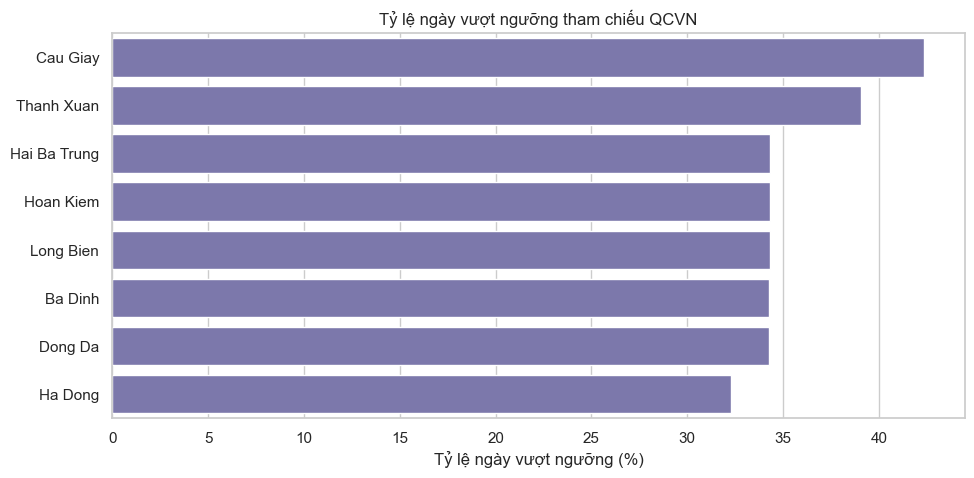

**Kết luận:** Cau Giay có tỷ lệ ngày vượt ngưỡng cao nhất: **42.4%** (591/1395 ngày hợp lệ).

In [7]:
daily = analysis_df.groupby(['station_id', 'location_name', 'date'], as_index=False).agg(
    pm25_daily=('pm25', 'mean'), hours=('pm25', 'count')
)
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.loc[daily['hours'] >= 18].copy()
daily['threshold'] = np.where(daily['date'] >= pd.Timestamp('2026-01-01'), 45.0, 50.0)
daily['exceeded'] = daily['pm25_daily'] > daily['threshold']

area_exceedance = daily.groupby(['station_id', 'location_name']).agg(
    days=('date', 'size'),
    exceed_days=('exceeded', 'sum'),
    pm25_daily_mean=('pm25_daily', 'mean'),
    pm25_daily_max=('pm25_daily', 'max'),
).reset_index()
area_exceedance['exceed_pct'] = area_exceedance['exceed_days'] / area_exceedance['days'] * 100
area_exceedance = area_exceedance.sort_values('exceed_pct', ascending=False)
display(area_exceedance.round(2))

ax = sns.barplot(data=area_exceedance, y='location_name', x='exceed_pct', color='#7570b3')
ax.set(title='Tỷ lệ ngày vượt ngưỡng tham chiếu QCVN', xlabel='Tỷ lệ ngày vượt ngưỡng (%)', ylabel='')
plt.show()
top_area = area_exceedance.iloc[0]
display(Markdown(
    f"**Kết luận:** {top_area['location_name']} có tỷ lệ ngày vượt ngưỡng cao nhất: "
    f"**{top_area['exceed_pct']:.1f}%** ({int(top_area['exceed_days'])}/{int(top_area['days'])} ngày hợp lệ)."
))

## 7. Có chu kỳ theo giờ hoặc theo mùa không?

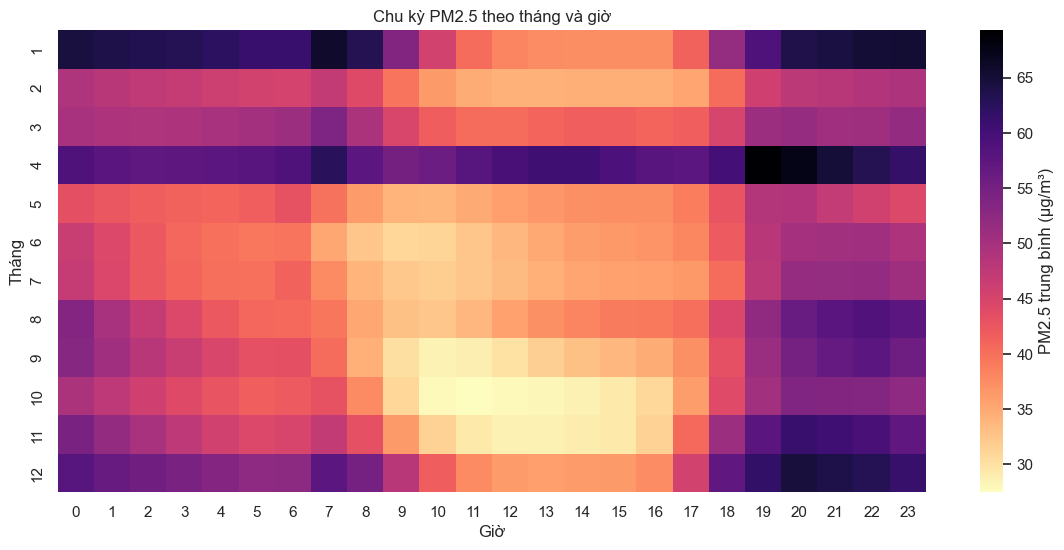

,season,mean,median,p90,count
0,Mùa xuân,49.05,41.9,86.1,70358
1,Mùa hè,41.62,36.9,71.0,58293
2,Mùa thu,42.22,35.5,78.2,69665
3,Mùa đông,49.45,40.4,94.8,69198


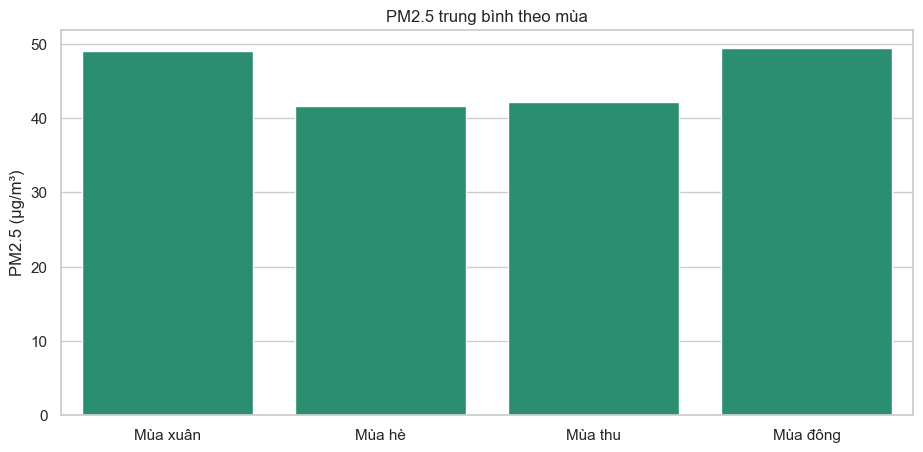

In [8]:
hour_month = analysis_df.pivot_table(index='month', columns='hour', values='pm25', aggfunc='mean')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(hour_month, cmap='magma_r', ax=ax, cbar_kws={'label': 'PM2.5 trung bình (µg/m³)'})
ax.set(title='Chu kỳ PM2.5 theo tháng và giờ', xlabel='Giờ', ylabel='Tháng')
plt.show()

season_map = {12: 'Mùa đông', 1: 'Mùa đông', 2: 'Mùa đông',
              3: 'Mùa xuân', 4: 'Mùa xuân', 5: 'Mùa xuân',
              6: 'Mùa hè', 7: 'Mùa hè', 8: 'Mùa hè',
              9: 'Mùa thu', 10: 'Mùa thu', 11: 'Mùa thu'}
season_order = ['Mùa xuân', 'Mùa hè', 'Mùa thu', 'Mùa đông']
analysis_df['season'] = pd.Categorical(
    analysis_df['month'].map(season_map), categories=season_order, ordered=True
)
season_stats = analysis_df.groupby('season', observed=True)['pm25'].agg(
    mean='mean', median='median', p90=lambda x: x.quantile(.90), count='size'
).reset_index()
display(season_stats.round(2))

ax = sns.barplot(data=season_stats, x='season', y='mean', color='#1b9e77')
ax.set(title='PM2.5 trung bình theo mùa', xlabel='', ylabel='PM2.5 (µg/m³)')
plt.show()
peak_season = season_stats.loc[season_stats['mean'].idxmax()]

## 8. Tổng hợp câu trả lời

In [9]:
display(Markdown(f"""
### Kết luận EDA

1. **Giờ PM2.5 cao:** giờ có trung bình cao nhất là **{int(peak_hour_row['hour']):02d}:00** ({peak_hour_row['mean']:.1f} µg/m³). Quan sát đơn lẻ cao nhất là **{max_row['pm25']:.1f} µg/m³** tại **{max_row['location_name']}**, lúc **{max_row['timestamp']}**.
2. **Ngày trong tuần:** **{worst_weekday['day']}** có trung bình cao nhất ({worst_weekday['mean']:.1f} µg/m³).
3. **Độ ẩm:** Spearman r = **{humidity_corr_spearman:.3f}** ({direction}, mức {strength}); không suy ra nhân quả.
4. **Gió:** nhóm gió mạnh có PM2.5 **{'thấp hơn' if wind_reduction > 0 else 'cao hơn'} {abs(wind_reduction):.1f}%** so với nhóm gió yếu; Spearman r = **{wind_corr:.3f}**.
5. **Khu vực vượt ngưỡng:** **{top_area['location_name']}** đứng đầu với **{top_area['exceed_pct']:.1f}%** ngày vượt ngưỡng tham chiếu.
6. **Chu kỳ:** PM2.5 trung bình cao nhất vào **{peak_season['season']}** ({peak_season['mean']:.1f} µg/m³); heatmap cho thấy tương tác rõ giữa tháng và giờ.

> Các kết luận mô tả dữ liệu CAMS/ERA5, không thay thế kết quả trạm quan trắc mặt đất hoặc phân tích nhân quả.
"""))


### Kết luận EDA

1. **Giờ PM2.5 cao:** giờ có trung bình cao nhất là **20:00** (56.3 µg/m³). Quan sát đơn lẻ cao nhất là **258.0 µg/m³** tại **Thanh Xuan**, lúc **2025-04-15 05:00:00+07:00**.
2. **Ngày trong tuần:** **Thứ Hai** có trung bình cao nhất (46.9 µg/m³).
3. **Độ ẩm:** Spearman r = **0.070** (cùng chiều, mức yếu); không suy ra nhân quả.
4. **Gió:** nhóm gió mạnh có PM2.5 **thấp hơn 44.7%** so với nhóm gió yếu; Spearman r = **-0.407**.
5. **Khu vực vượt ngưỡng:** **Cau Giay** đứng đầu với **42.4%** ngày vượt ngưỡng tham chiếu.
6. **Chu kỳ:** PM2.5 trung bình cao nhất vào **Mùa đông** (49.5 µg/m³); heatmap cho thấy tương tác rõ giữa tháng và giờ.

> Các kết luận mô tả dữ liệu CAMS/ERA5, không thay thế kết quả trạm quan trắc mặt đất hoặc phân tích nhân quả.


## 9. Giới hạn phân tích

- Chất lượng không khí đến từ CAMS Global, độ phân giải không gian khoảng 45 km và thời gian gốc 3 giờ; nhiều điểm nội thành có thể dùng chung ô lưới.
- Dữ liệu bắt đầu thực tế từ 04/08/2022, không bao phủ 01/01–03/08/2022.
- Phân tích tương quan chưa kiểm soát đồng thời mùa, mưa, nhiệt độ, giao thông và tự tương quan thời gian.
- So sánh QCVN chỉ mang tính sàng lọc vì đơn vị/điều kiện chuẩn và phương pháp quan trắc khác với dữ liệu mô hình.
- Bước tiếp theo nên dùng mô hình hồi quy đa biến hoặc time-series để kiểm soát các yếu tố gây nhiễu.